# TITLE

## Infos zu Experiment:
- Zustand Zellen, Benutzte FBS Konz., Dichte der Zellen, Wartezeit etc. 

## Data Loading and Preprocessing

### Load required libraries and specify the data folder

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.express as px
import seaborn as sns
import numpy as np
import scipy
from scipy.stats import pearsonr, spearmanr
from scipy.integrate import simpson

data_folder = "\\\\izbkingston.unibe.ch\\imaging.data\\PertzLab\\optoRTK_CedricZ\\experimental_data"
experiment_name = "2025-09-04_RampReverse"
exp_path = os.path.join(data_folder, experiment_name)


### Load analysed data from rtm-pymmcore experiment

This loads the data from the individual field of views and create one big dataframe. This dataframe is then saved in your local folder and used to plot the data.

In [2]:
track_folder = "tracks" 
fovs = os.listdir(os.path.join(exp_path, track_folder))
os.makedirs("figures", exist_ok=True)
fovs.sort()
dfs = []
for fov in fovs:
    track_file = os.path.join(exp_path, track_folder, fov)
    df = pd.read_parquet(track_file)
    dfs.append(df)
df = pd.concat(dfs)
df.to_parquet("data.parquet")

In [3]:
df

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,stim_exposure_list,stim_timestep,stim_power,stim_channel_name,stim_channel_group,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,optocheck_mean_intensity
0,3420.535714,2707.004464,4,124.031250,780.486607,224.0,3341.0,2599.5,1551.175439,1427.850877,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,788.137255
1,2087.790698,2635.392027,5,130.827243,572.481728,301.0,2057.0,2710.0,636.519231,1183.467949,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,229.202247
2,2503.929907,1851.817757,6,133.780374,479.682243,214.0,2576.0,1858.5,615.817518,1173.021898,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,233.253731
3,1581.276956,2173.815011,7,156.329810,42.987315,946.0,1513.0,2159.5,559.651822,1967.429150,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,261.303337
4,2713.152685,3160.317114,9,217.395973,181.206376,596.0,2635.0,3122.0,756.402985,3288.393035,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,348.209192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3962,3970.079245,6564.569811,22,806.207547,676.286792,265.0,3960.0,6914.0,1580.432432,3000.873874,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,345.105660
3963,2540.629526,8075.732591,23,825.270195,665.284123,359.0,2498.0,8072.0,1040.716312,5186.241135,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,273.454039
3964,6013.431217,8209.658730,24,897.367725,575.706349,378.0,6046.0,8191.5,1809.082353,6537.964706,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,264.190476
3965,2225.008065,5196.616935,25,898.048387,781.842742,496.0,2170.0,5389.5,882.026738,2550.807487,...,"[700, 695, 690, 685, 680, 675, 670, 665, 660, ...","[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 2...",3,CyanStim,TTL_ERK,Spectra,Cyan_Level,NaN,False,249.647177


### Data clean-up
Add Cytoplasma to nuclear ratio based on measured intensities. Further normalise according to the first few frames. Remove cells which were not tracked for 80% of the frames.

In [ ]:
df = pd.read_parquet("data.parquet")

In [14]:
df["cnr"] = df["mean_intensity_C1_ring"] / df["mean_intensity_C1_nuc"]
df["cnr_median"] = df["median_intensity_C1_ring"] / df["median_intensity_C1_nuc"]
df["uid"] = df["fov"].astype("string") + "_" + df["particle"].astype("string")
df['cell_id'] = df['cell_line'].astype(str) + '_' + df['uid'].astype(str)
df["frame"] = df["timestep"]
df["stim_timestep_str"] = df["stim_timestep"].apply(str) 

frame_counts = df["uid"].value_counts()
threshold = 0.9 * frame_counts.max()

valid_uids = frame_counts[frame_counts >= threshold].index
df = df[df["uid"].isin(valid_uids)]

C:\Users\czahn\AppData\Local\Temp\ipykernel_13220\3899868145.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cnr"] = df["mean_intensity_C1_ring"] / df["mean_intensity_C1_nuc"]
C:\Users\czahn\AppData\Local\Temp\ipykernel_13220\3899868145.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cnr_median"] = df["median_intensity_C1_ring"] / df["median_intensity_C1_nuc"]
C:\Users\czahn\AppData\Local\Temp\ipykernel_13220\3899868145.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of 

### Median

In [ ]:
NORM_UNTIL_TIMEPOINT = 10
median_cnr_first_ten_frames = df[df['frame'] < NORM_UNTIL_TIMEPOINT].groupby('uid')['cnr_median'].median()
def normalize_cnr(row):
    return row['cnr_median'] / median_cnr_first_ten_frames[row['uid']] if row['uid'] in median_cnr_first_ten_frames else np.nan
df["cnr_median_norm"] = df.apply(normalize_cnr, axis=1)
df.dropna(subset=["cnr_median_norm"], inplace=True) 

### Mean

In [5]:
NORM_UNTIL_TIMEPOINT = 10
mean_cnr_first_ten_frames = df[df['frame'] < NORM_UNTIL_TIMEPOINT].groupby('uid')['cnr'].median()
def normalize_cnr(row):
    return row['cnr'] / mean_cnr_first_ten_frames[row['uid']] if row['uid'] in mean_cnr_first_ten_frames else np.nan
df["cnr_norm"] = df.apply(normalize_cnr, axis=1)
df.dropna(subset=["cnr_norm"], inplace=True) 

C:\Users\czahn\AppData\Local\Temp\ipykernel_13220\3492331511.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["cnr_norm"] = df.apply(normalize_cnr, axis=1)
C:\Users\czahn\AppData\Local\Temp\ipykernel_13220\3492331511.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(subset=["cnr_norm"], inplace=True)


In [15]:
df

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,optocheck_mean_intensity,uid,cell_id,frame,cnr_norm,stim_timestep_str
0,3420.535714,2707.004464,4,124.031250,780.486607,224.0,3341.0,2599.5,1551.175439,1427.850877,...,Spectra,Cyan_Level,NaN,False,788.137255,0_3,FGFR_0_3,0,1.004111,[ 10 11 12 13 14 15 16 17 18 19 20 ...
1,2087.790698,2635.392027,5,130.827243,572.481728,301.0,2057.0,2710.0,636.519231,1183.467949,...,Spectra,Cyan_Level,NaN,False,229.202247,0_4,FGFR_0_4,0,1.036237,[ 10 11 12 13 14 15 16 17 18 19 20 ...
2,2503.929907,1851.817757,6,133.780374,479.682243,214.0,2576.0,1858.5,615.817518,1173.021898,...,Spectra,Cyan_Level,NaN,False,233.253731,0_5,FGFR_0_5,0,1.131875,[ 10 11 12 13 14 15 16 17 18 19 20 ...
3,1581.276956,2173.815011,7,156.329810,42.987315,946.0,1513.0,2159.5,559.651822,1967.429150,...,Spectra,Cyan_Level,NaN,False,261.303337,0_6,FGFR_0_6,0,1.029815,[ 10 11 12 13 14 15 16 17 18 19 20 ...
4,2713.152685,3160.317114,9,217.395973,181.206376,596.0,2635.0,3122.0,756.402985,3288.393035,...,Spectra,Cyan_Level,NaN,False,348.209192,0_7,FGFR_0_7,0,1.187484,[ 10 11 12 13 14 15 16 17 18 19 20 ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3960,5696.737166,19643.277207,20,693.673511,630.741273,487.0,5645.0,20079.0,1701.500000,9113.405941,...,Spectra,Cyan_Level,NaN,False,490.375770,35_17,TrkA_35_17,179,0.977265,[ 10 11 12 13 14 15 16 17 18 19 20 ...
3961,3078.133475,5848.940678,21,770.771186,461.783898,472.0,3075.0,5903.0,892.711230,2685.914439,...,Spectra,Cyan_Level,NaN,False,259.010593,35_18,TrkA_35_18,179,1.034686,[ 10 11 12 13 14 15 16 17 18 19 20 ...
3964,6013.431217,8209.658730,24,897.367725,575.706349,378.0,6046.0,8191.5,1809.082353,6537.964706,...,Spectra,Cyan_Level,NaN,False,264.190476,35_20,TrkA_35_20,179,1.017131,[ 10 11 12 13 14 15 16 17 18 19 20 ...
3965,2225.008065,5196.616935,25,898.048387,781.842742,496.0,2170.0,5389.5,882.026738,2550.807487,...,Spectra,Cyan_Level,NaN,False,249.647177,35_21,TrkA_35_21,179,0.946234,[ 10 11 12 13 14 15 16 17 18 19 20 ...


Delete specific fucked-up cells

In [ ]:
df_manual_filtering = pd.read_csv(os.path.join(exp_path, "cell_selection.csv"))
df_manual_filtering

In [6]:
# Step 1: Get list of uids to delete
uids_to_delete = df_manual_filtering[df_manual_filtering["deleted"] == True]["uid"]

# Step 2: Remove these uids from the main dataframe
df = df[~df["uid"].isin(uids_to_delete)]
df = df[~df["uid"].astype(str).str.startswith("12")]

NameError: name 'df_manual_filtering' is not defined

In [7]:
df

,mean_intensity_C0_nuc,mean_intensity_C1_nuc,label,x,y,area,median_intensity_C0_nuc,median_intensity_C1_nuc,mean_intensity_C0_ring,mean_intensity_C1_ring,...,stim_channel_group,stim_channel_device_name,stim_channel_power_property_name,stim_exposure,stim,optocheck_mean_intensity,uid,cell_id,frame,cnr_norm
0,3420.535714,2707.004464,4,124.031250,780.486607,224.0,3341.0,2599.5,1551.175439,1427.850877,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,788.137255,0_3,FGFR_0_3,0,1.004111
1,2087.790698,2635.392027,5,130.827243,572.481728,301.0,2057.0,2710.0,636.519231,1183.467949,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,229.202247,0_4,FGFR_0_4,0,1.036237
2,2503.929907,1851.817757,6,133.780374,479.682243,214.0,2576.0,1858.5,615.817518,1173.021898,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,233.253731,0_5,FGFR_0_5,0,1.131875
3,1581.276956,2173.815011,7,156.329810,42.987315,946.0,1513.0,2159.5,559.651822,1967.429150,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,261.303337,0_6,FGFR_0_6,0,1.029815
4,2713.152685,3160.317114,9,217.395973,181.206376,596.0,2635.0,3122.0,756.402985,3288.393035,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,348.209192,0_7,FGFR_0_7,0,1.187484
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3960,5696.737166,19643.277207,20,693.673511,630.741273,487.0,5645.0,20079.0,1701.500000,9113.405941,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,490.375770,35_17,TrkA_35_17,179,0.977265
3961,3078.133475,5848.940678,21,770.771186,461.783898,472.0,3075.0,5903.0,892.711230,2685.914439,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,259.010593,35_18,TrkA_35_18,179,1.034686
3964,6013.431217,8209.658730,24,897.367725,575.706349,378.0,6046.0,8191.5,1809.082353,6537.964706,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,264.190476,35_20,TrkA_35_20,179,1.017131
3965,2225.008065,5196.616935,25,898.048387,781.842742,496.0,2170.0,5389.5,882.026738,2550.807487,...,TTL_ERK,Spectra,Cyan_Level,NaN,False,249.647177,35_21,TrkA_35_21,179,0.946234


Calculate ERK-activity baseline for each cell_id

In [ ]:
# Calculate the mean CNR for each cell_id from timestep 0 to 9
# Step 1: Filter to frames 0–9
df_0_9 = df[(df['frame'] >= 0) & (df['frame'] <= 9)].copy()

# Step 2: Group by 'cell_id' and calculate the median cnr
median_cnr = df_0_9.groupby('cell_id')['cnr'].median().reset_index()
median_cnr.rename(columns={'cnr': 'median_cnr_0_9'}, inplace=True)

# Step 3: Merge the median_cnr back into the main df
df = df.merge(median_cnr, on='cell_id', how='left')

In [ ]:
df.to_parquet("data_filtered.parquet")

# CSV Export

In [ ]:
df[["cell_line", "uid", "stim_power", "stim_exposure", "stim_timestep", "optocheck_mean_intensity", "timestep", "cnr_median", "cnr_norm"]].to_csv("filtered_data.csv", index=False)

## Results

In [ ]:
df = pd.read_parquet("data_filtered.parquet")

### Multiple Stimulation

#### Not normalised

In [16]:
POWER_TO_PLOT = 3
df_plot = df.query("stim_power == @POWER_TO_PLOT")
df_plot.loc[:, "stim_timestep"] = df_plot["stim_timestep"].apply(tuple)
df_plot["stim_timestep"].unique()
cell_lines = df_plot["cell_line"].unique()

#### not normalised

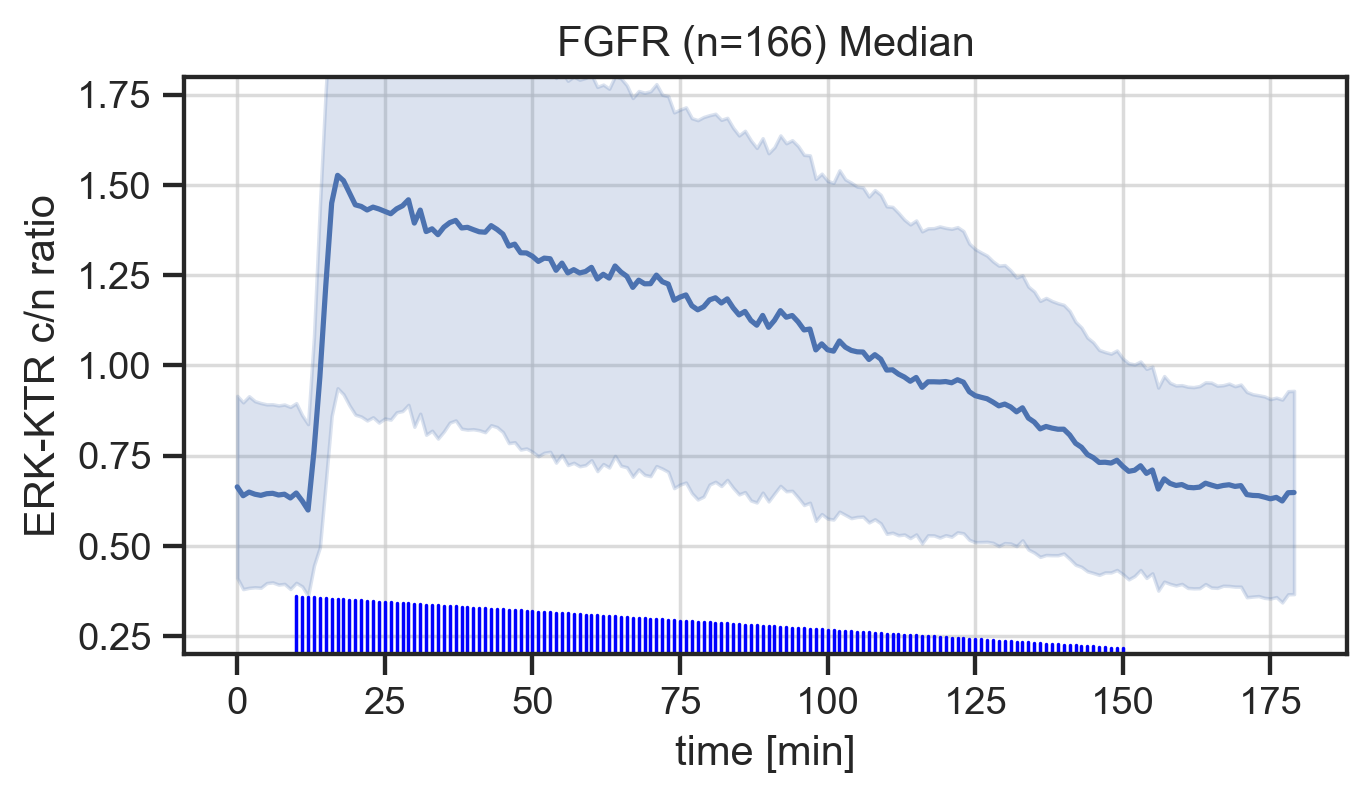

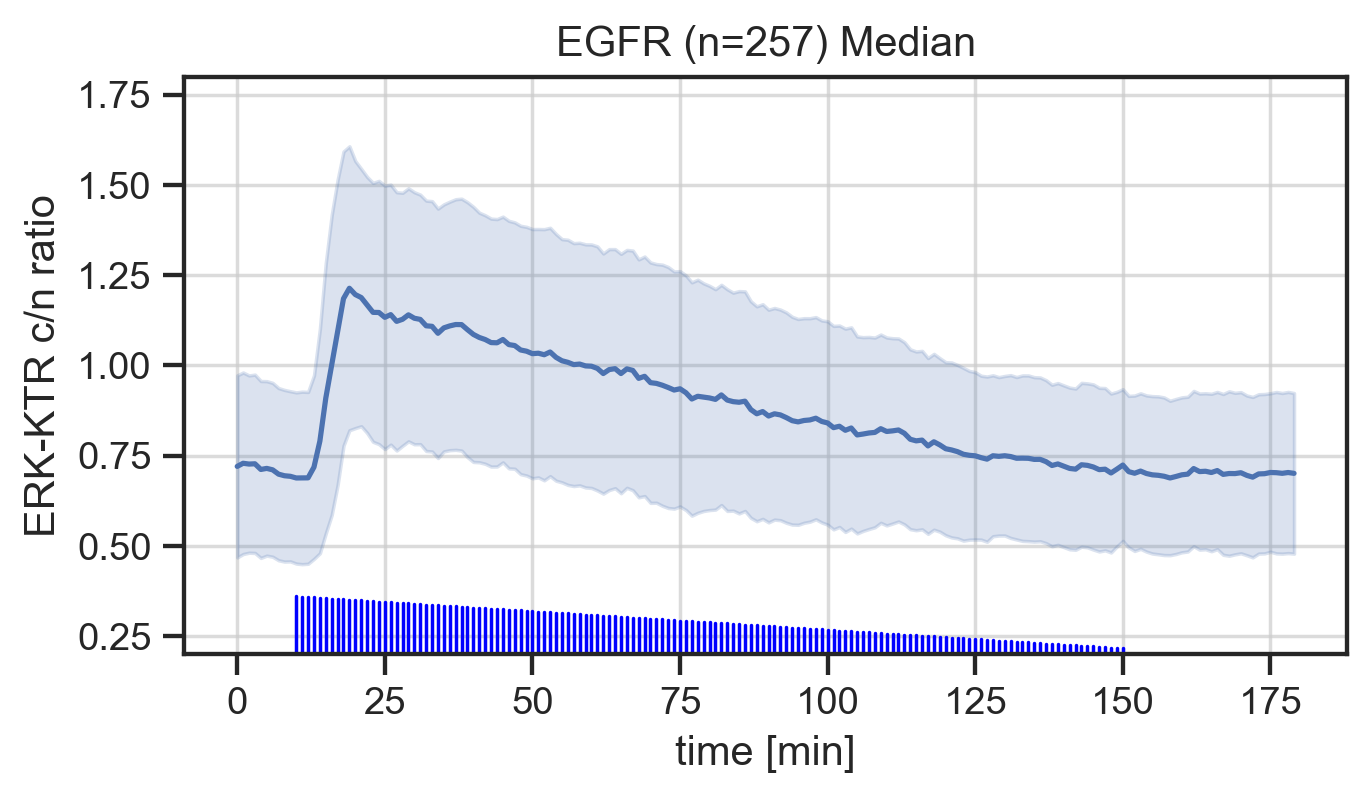

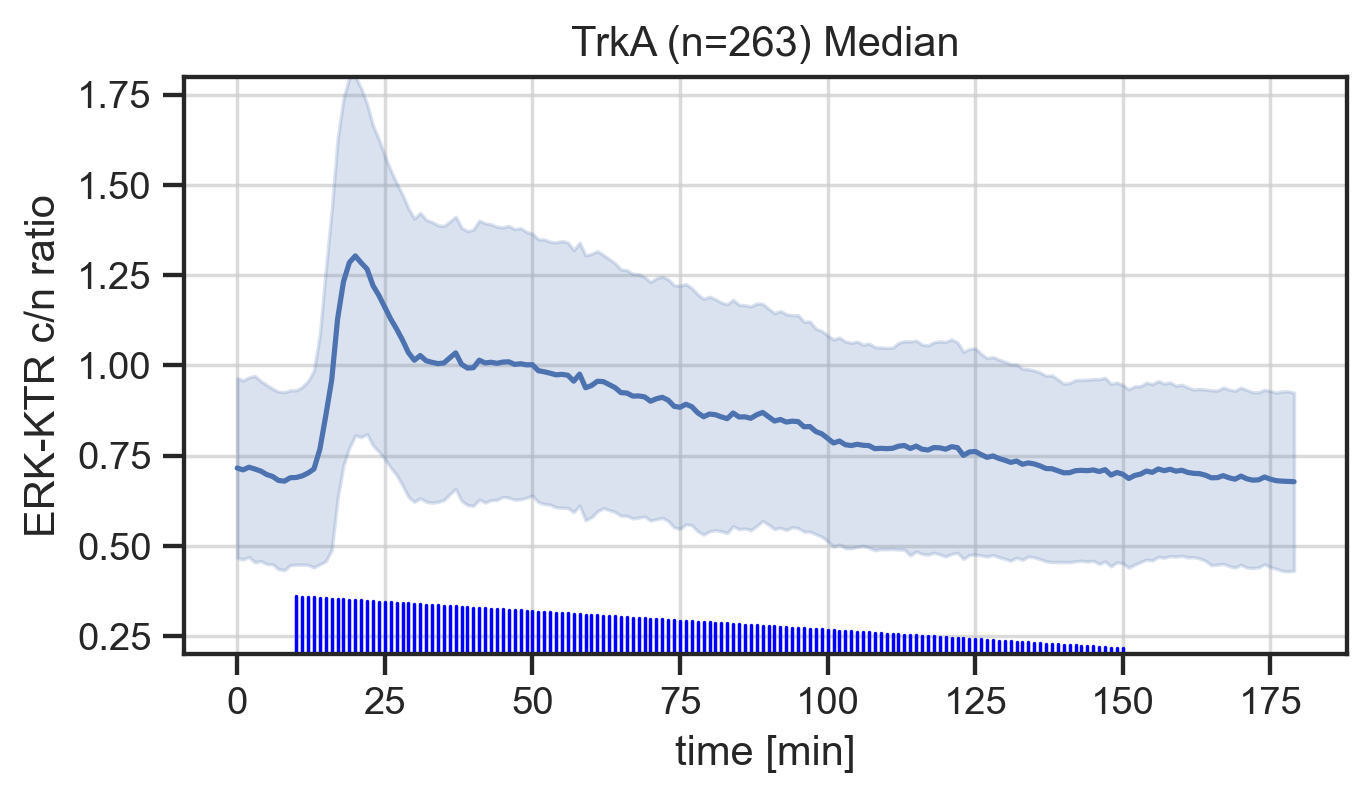

In [17]:
for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3),dpi = 250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()

    plt.grid(True, linestyle='-', alpha=0.7)

    sns.lineplot(data=df_plot.query("cell_line == @cell_line"), x='frame', y='cnr_median', estimator = "median", errorbar='sd')
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        num_cells_exposure = df_plot.query("cell_line == @cell_line")["uid"].nunique()
        new_labels.append(f'{label} (n={num_cells_exposure})')
    plt.ylabel('ERK-KTR c/n ratio')
    plt.xlabel('time [min]')
    x_start = 10
    x_end = 150

    for x in range(x_start, x_end + 1):
        # Normalize x between 0 and 1
        t = 1 - (x - x_start) / (x_end - x_start)
        # Map to desired ymax range
        ymax = 0.01 + t * (0.1 - 0.01)
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)

    plt.ylim(0.2, 1.8)
    plt.title(f"{cell_line} (n={num_cells}) Median")
    plt.legend([], [], frameon=False)
    plt.savefig(f"figures/{cell_line}_multi_erkktr.png", bbox_inches='tight')
    plt.show()

individual traces

<Figure size 3600x1800 with 0 Axes>

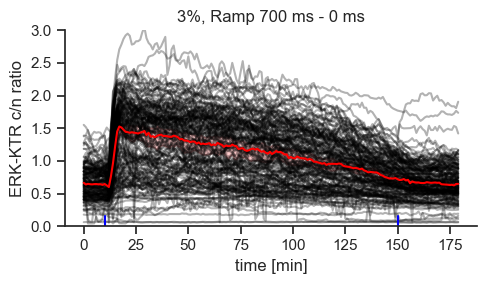

<Figure size 3600x1800 with 0 Axes>

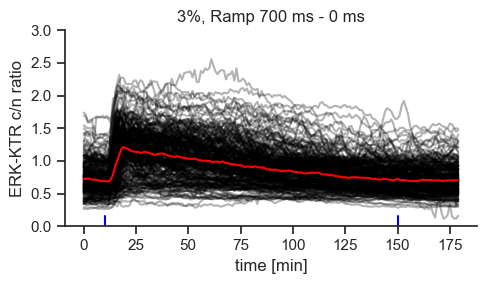

<Figure size 3600x1800 with 0 Axes>

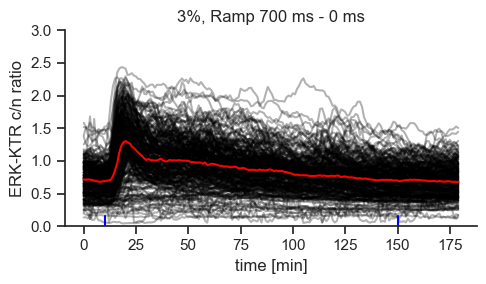

In [23]:
for cell_line in cell_lines: 
    plt.figure(figsize=(12, 6), dpi=300)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()
    sns.set_theme(style="ticks")
    
    # Create the FacetGrid
    g = sns.FacetGrid(
        df_plot.query("cell_line == @cell_line"), 
        col="stim_timestep_str", 
        col_wrap=3, 
        height=3, 
        aspect=1.5
    )
    
    # Plot individual traces and mean with confidence interval
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', units="uid", estimator=None, color="black", alpha=0.3)
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', errorbar=('ci', 90), color="red", estimator="median")
    
    
    # Add vertical lines for stim_timestep
    for x in [10, 150]:
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=0.05, linewidth=1.5)
    
    # g.map_dataframe(add_vertical_lines)
    
    # Set axis labels and titles
    g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
    # Override all subplot titles
    for ax in g.axes.flat:
        ax.set_title("3%, Ramp 700 ms - 0 ms")
    g.set(ylim=(0, 3))

    g.tight_layout()
    
    # Save and show the plot
    plt.savefig(f"figures/{cell_line}_multi_traces_erkktr.png", bbox_inches='tight')
    plt.show()

#### normalised

In [ ]:
cell_lines = df_plot["cell_line"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3),dpi = 250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()

    sns.lineplot(data=df_plot.query("cell_line == @cell_line"), x='frame', y='cnr_norm', hue="stim_timestep_str", palette="tab10", errorbar=('ci',90))
    handles, labels = plt.gca().get_legend_handles_labels()
    new_labels = []
    for label in labels:
        num_cells_exposure = df_plot.query("cell_line == @cell_line and stim_timestep_str == @label")["uid"].nunique()
        new_labels.append(f'{label} (n={num_cells_exposure})')
    plt.ylabel('norm ERK-KTR c/n ratio')
    plt.xlabel('time [min]')
    plt.axvline(x=10, color='black', linestyle='--')
    plt.title(f"{cell_line} (n={num_cells})")
    plt.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3, frameon=False)
    plt.savefig(f"figures/{cell_line}_multi_norm_erkktr.svg", bbox_inches='tight')
    plt.show()

individual traces

In [ ]:
EXPOSURE_TO_PLOT = 100
cell_lines = df_plot["cell_line"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    plt.figure(figsize=(6, 3), dpi=250)
    num_cells = df_plot.query("cell_line == @cell_line")["uid"].nunique()
    sns.set_theme(style="ticks")
    
    # Create the FacetGrid
    g = sns.FacetGrid(
        df_plot.query("cell_line == @cell_line"), 
        col="stim_timestep_str", 
        col_wrap=3, 
        height=3, 
        aspect=1.5
    )
    
    # Plot individual traces and mean with confidence interval
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', units="uid", estimator=None, color="black", alpha=0.3)
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', errorbar=('ci', 90), color="red", estimator="mean")
    
    # Add vertical lines for stim_timestep
    def add_vertical_lines(data, **kwargs):
        stim_timesteps = data["stim_timestep"].unique()
        for stim_timestep in stim_timesteps[0]:
            plt.axvline(x=stim_timestep, color='blue', linestyle='--', alpha=0.7)
    
    g.map_dataframe(add_vertical_lines)
    
    # Set axis labels and titles
    g.set_axis_labels('time [min]', 'norm. ERK-KTR c/n ratio')
    g.set_titles(col_template="{col_name}")
    g.set(ylim=(0.7, None))
    g.tight_layout()
    
    # Save and show the plot
    plt.savefig(f"figures/{cell_line}_multi_traces_erkktr_norm.png", bbox_inches='tight')
    plt.show()

## Random Subplots

Not Normalized

<Figure size 1500x750 with 0 Axes>

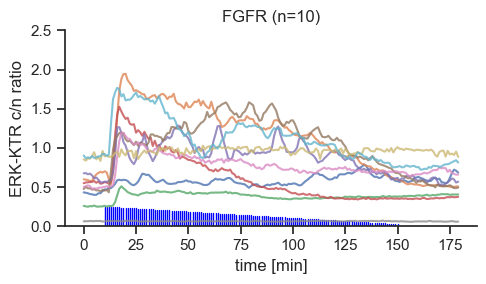

<Figure size 1500x750 with 0 Axes>

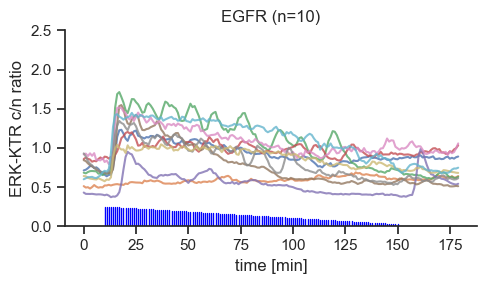

<Figure size 1500x750 with 0 Axes>

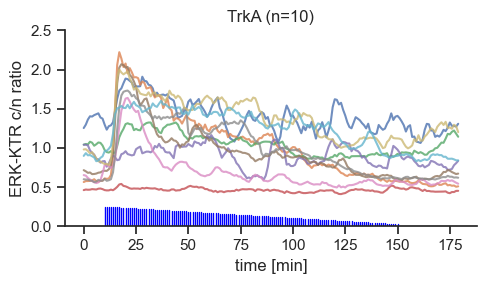

In [27]:
for cell_line in cell_lines: 
    # Filter for this cell line
    df_cell = df_plot.query("cell_line == @cell_line")

    # Get 10 random unique uids
    sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

    # Filter the data to only these 10 cells
    df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

    plt.figure(figsize=(6, 3), dpi=250)
    sns.set_theme(style="ticks")
    
    g = sns.FacetGrid(
        df_sub, 
        col="stim_timestep_str", 
        col_wrap=3, 
        height=3, 
        aspect=1.5
    )

    x_start = 10
    x_end = 150

    for x in range(x_start, x_end + 1):
        # Normalize x between 0 and 1
        t = 1 - (x - x_start) / (x_end - x_start)
        # Map to desired ymax range
        ymax = 0.01 + t * (0.1 - 0.01)
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)
    
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', hue='uid', estimator=None, alpha=0.8)
    g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
    for ax in g.axes.flat:
        ax.set_title("Ramp 50 ms - 300 ms")
    g.set(ylim=(0, 2.5))
    g.tight_layout()
    
    plt.title(f"{cell_line} (n=10)")
    plt.savefig(f"figures/{cell_line}_10random_erkktr.png", bbox_inches='tight')
    plt.show()

Normalized

<Figure size 1500x750 with 0 Axes>

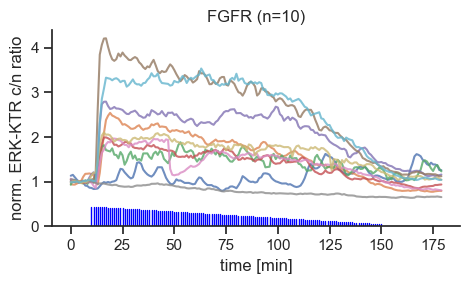

<Figure size 1500x750 with 0 Axes>

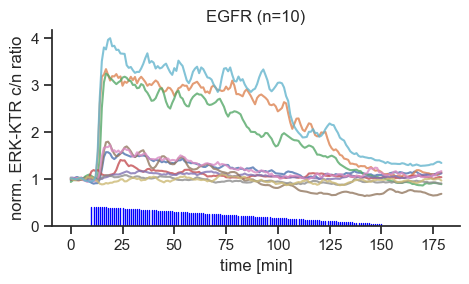

<Figure size 1500x750 with 0 Axes>

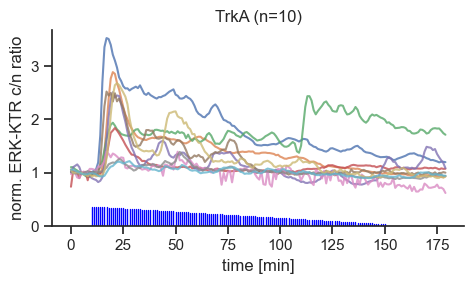

In [31]:
for cell_line in cell_lines: 
    # Filter for this cell line
    df_cell = df_plot.query("cell_line == @cell_line")

    # Get 10 random unique uids
    sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

    # Filter the data to only these 10 cells
    df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

    plt.figure(figsize=(6, 3), dpi=250)
    sns.set_theme(style="ticks")
    
    g = sns.FacetGrid(
        df_sub, 
        col="stim_timestep_str", 
        col_wrap=3, 
        height=3, 
        aspect=1.5
    )

    x_start = 10
    x_end = 150

    for x in range(x_start, x_end + 1):
        # Normalize x between 0 and 1
        t = 1 - (x - x_start) / (x_end - x_start)
        # Map to desired ymax range
        ymax = 0.01 + t * (0.1 - 0.01)
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)
    
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_norm', hue='uid', estimator=None, alpha=0.8)
    g.set_axis_labels('time [min]', 'norm. ERK-KTR c/n ratio')
    for ax in g.axes.flat:
        ax.set_title("Ramp 50 ms - 300 ms")
    g.set(ylim=(0, None))
    g.tight_layout()
    
    plt.title(f"{cell_line} (n=10)")
    plt.savefig(f"figures/{cell_line}_10random_erkktr_norm.png", bbox_inches='tight')
    plt.show()

## Responders

In [ ]:
# Responders are Cells that show a higher CNR at timepoint 16 compared to median_cnr_0_9 (10% more)
# Step 1: Get the cnr at timestep 16 for each uid
cnr_tp16 = df[df["timestep"] == 16][["uid", "cnr_median"]].rename(columns={"cnr_median": "cnr_16"})

# Step 2: Merge with median_cnr_0_9 (must already be a column in df or another DataFrame)
# If it's in the main df:
baseline = df[["uid", "median_cnr_0_9"]].drop_duplicates()

# Step 3: Combine data
df_resp = cnr_tp16.merge(baseline, on="uid", how="inner")

# Step 4: Add a "responder" column: True if cnr_16 > 1.1 × baseline
df_resp["responder"] = df_resp["cnr_16"] > 1.1 * df_resp["median_cnr_0_9"]

# Step 5: Merge back into main df if you want
df = df.merge(df_resp[["uid", "responder"]], on="uid", how="left")
df["responder"] = df["responder"].fillna(False)  # default to False for unmatched uids

In [ ]:
# Step 1: Get one row per uid with responder info
df_cells = df[["uid", "cell_line", "responder"]].drop_duplicates()

# Step 2: Group and count responders/non-responders
responder_counts = (
    df_cells
    .groupby(["cell_line", "responder"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: "Responder", False: "Non-Responder"})
)

# Step 3: Normalize to get proportions
responder_props = responder_counts.div(responder_counts.sum(axis=1), axis=0)

# Step 4: Plot as stacked barplot
responder_props.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    color=["lightgray", "seagreen"],
    edgecolor="black"
)

plt.ylabel("Proportion")
plt.title("Proportion of Responders by Cell Line and Stim Exposure")
plt.legend(title="Response")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
for cell_line in cell_lines: 
    # Filter for Responders
    df_cell = df_plot.query("cell_line == @cell_line and responder == True")

    # Get 10 random unique uids
    sampled_uids = np.random.choice(df_cell["uid"].unique(), size=10, replace=False)

    # Filter the data to only these 10 cells
    df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

    plt.figure(figsize=(6, 3), dpi=250)
    sns.set_theme(style="ticks")
    
    g = sns.FacetGrid(
        df_sub, 
        col="stim_timestep_str", 
        col_wrap=3, 
        height=3, 
        aspect=1.5
    )

    x_start = 10
    x_end = 150

    for x in range(x_start, x_end + 1):
        # Normalize x between 0 and 1
        t = 1 - (x - x_start) / (x_end - x_start)
        # Map to desired ymax range
        ymax = 0.01 + t * (0.1 - 0.01)
        plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)
    
    g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', hue='uid', estimator=None, alpha=0.8)
    g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
    for ax in g.axes.flat:
        ax.set_title("Ramp 50 ms - 300 ms")
    g.set(ylim=(0, 2.2))
    g.tight_layout()
    
    plt.title(f"{cell_line} (n=10)")
    # plt.savefig(f"figures/{cell_line}_10random_erkktr.png", bbox_inches='tight')
    plt.show()

## Subplots for every FOV

In [ ]:
cell_line_fovs = {
    "FGFR": [0, 1, 2, 3, 4, 15, 16, 17, 18, 19],
    "EGFR": [5, 6, 7, 8, 9, 20, 21, 22, 23, 24],
    "TrkA": [10, 11, 12, 13, 14, 25, 26, 27, 28, 29],
}

In [ ]:
cell_lines = df_plot["cell_line"].unique()
fovs = df_plot["fov"].unique()
df_plot.loc[:, "stim_exposure"] = df_plot.loc[:, "stim_exposure"].astype("int")

for cell_line in cell_lines: 
    for fov in cell_line_fovs[cell_line]:
        plt.figure(figsize=(6, 3),dpi = 250)
        num_cells = df_plot.query("cell_line == @cell_line & fov == @fov")["uid"].nunique()

        plt.grid(True, linestyle='-', alpha=0.7)

        sns.lineplot(data=df_plot.query("cell_line == @cell_line & fov == @fov" ), x='frame', y='cnr_median', estimator = "median", errorbar='sd')
        handles, labels = plt.gca().get_legend_handles_labels()
        new_labels = []
        for label in labels:
            num_cells_exposure = df_plot.query("cell_line == @cell_line & fov == @fov")["uid"].nunique()
            new_labels.append(f'{label} (n={num_cells_exposure})')
        plt.ylabel('ERK-KTR c/n ratio')
        plt.xlabel('time [min]')
        x_start = 10
        x_end = 150

        for x in range(x_start, x_end + 1):
            # Normalize x between 0 and 1
            t = 1 - (x - x_start) / (x_end - x_start)
            # Map to desired ymax range
            ymax = 0.01 + t * (0.1 - 0.01)
            plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)

        plt.ylim(0.3, 1.8)
        plt.title(f"{cell_line} {fov} (n={num_cells}) Median")
        plt.legend([], [], frameon=False)
        plt.savefig(f"figures/{cell_line}_{fov}_multi_erkktr.png", bbox_inches='tight')
        plt.show()

In [ ]:
for cell_line in cell_lines: 
    for fov in cell_line_fovs[cell_line]:
        # Filter for this cell line
        df_cell = df_plot.query("cell_line == @cell_line & fov == @fov")

        # Get 10 random unique uids
        sampled_uids = np.random.choice(df_cell["uid"].unique(), size=9, replace=False)

        # Filter the data to only these 10 cells
        df_sub = df_cell[df_cell["uid"].isin(sampled_uids)]

        plt.figure(figsize=(6, 3), dpi=250)
        sns.set_theme(style="ticks")
        
        g = sns.FacetGrid(
            df_sub, 
            col="stim_timestep_str", 
            col_wrap=3, 
            height=3, 
            aspect=1.5
        )

        x_start = 10
        x_end = 150

        for x in range(x_start, x_end + 1):
            # Normalize x between 0 and 1
            t = 1 - (x - x_start) / (x_end - x_start)
            # Map to desired ymax range
            ymax = 0.01 + t * (0.1 - 0.01)
            plt.axvline(x=x, color='blue', linestyle='-', ymin=0.0, ymax=ymax, linewidth=1)
        
        g.map_dataframe(sns.lineplot, x='frame', y='cnr_median', hue='uid', estimator=None, alpha=0.8)
        g.set_axis_labels('time [min]', 'ERK-KTR c/n ratio')
        for ax in g.axes.flat:
            ax.set_title("Ramp 50 ms - 300 ms")
        g.set(ylim=(0, 2.2))
        g.tight_layout()
        
        plt.title(f"{cell_line} {fov} (n=10)")
        plt.savefig(f"figures/{cell_line}_{fov}_10random_erkktr.png", bbox_inches='tight')
        plt.show()

## Cell Density

In [ ]:
# Count the unique cells per fov
cell_counts = df_plot.groupby('fov')['uid'].nunique().reset_index()
cell_counts

In [ ]:
 # Define 3 subpopulations: low density (<20), medium density (20-50), high density (>50) 
df_counts = cell_counts.copy()
def density_category(count):
    if count < 20:
        return 'Low Density (<20)'
    elif 20 <= count <= 50:
        return 'Medium Density (20-50)'
    else:
        return 'High Density (>50)'
df_counts['density_category'] = df_counts['uid'].apply(density_category)
df_counts
df = df.merge(df_counts[['fov', 'density_category']], on='fov', how='left')

# Export Data for Meta Analysis

In [ ]:
df["uid"] = "25_" + df["uid"].astype(str)
df["experiment"] = 25


In [ ]:
df[["cell_line", "uid", "stim_power", "stim_exposure", "stim_timestep", "optocheck_mean_intensity", "timestep", "cnr_median", "cnr_norm", "density_category", "experiment"]].to_parquet("MetaReverse_2025-08-25.parquet", index=False)

In [ ]:
df